# Machine Learning II Project - PCOS Diagnosis

In [47]:
# import
import kagglehub
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch
import math
import torch.nn as nn
import cv2
from pathlib import Path
from PIL import Image
import numpy as np

## A quick look at the data

In [48]:
path = kagglehub.dataset_download("anaghachoudhari/pcos-detection-using-ultrasound-images")

In [49]:
def valid(path):
    """Helper function to remove broken images."""
    try:
        with Image.open(path) as img:
            img.verify()
            return True
    except:
        return False

In [50]:
[p.unlink() for p in Path(path).iterdir() if p.is_file() and not valid(p)]

[]

In [51]:
def import_data(path):
    # prepare pipeline
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),  # make sure images have the same size
        transforms.ToTensor()
    ])

    # load training data. -> placeholder for now
    train_dataset = datasets.ImageFolder(root=os.path.join(path, "data", "train"), transform=transform)

    # load test data. -> placeholder for now
    test_dataset = datasets.ImageFolder(root=os.path.join(path, "data", "test"), transform=transform)

    return train_dataset, test_dataset

In [52]:
train_dataset, test_dataset = import_data(path)

In [53]:
def display_examples(data, show=False):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    infected_example, _ = data[0]
    not_infected_example, _ = data[-1]

    ax[0].imshow(infected_example.permute(1, 2, 0), cmap="gray")
    ax[0].set_title("Infected")

    ax[1].imshow(not_infected_example.permute(1, 2, 0), cmap="gray")
    ax[1].set_title("Not Infected")

    if show:
        plt.show()

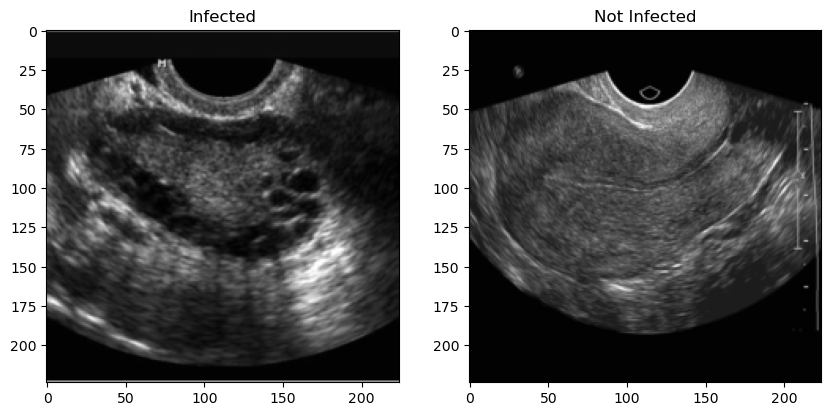

In [54]:
display_examples(train_dataset)

In [55]:
type(train_dataset[0][0])

torch.Tensor

## Manual model

In [62]:
class ImageSegmentation:
    def __init__(self, image):
        # We store the normalized version immediately
        self.img = self.to_gray_uint8(image)

    def to_gray_uint8(self, image):
        img = np.asarray(image)
        
        img = img.astype(np.float32)
        # Normalize to 0-255 range (Lecture 05: Contrast Stretching)
        cv2.normalize(img, img, 0, 255, cv2.NORM_MINMAX)
        return img.astype(np.uint8)

    def intensity_transformation(self, gamma=1.1):
        """
        Lecture 05: Balanced Gamma. 
        If gamma is too high, everything becomes black. 
        1.2 - 1.5 is usually the 'sweet spot' for ultrasound.
        """
        invGamma = 1.0 / gamma
        table = np.array([((i / 255.0) ** invGamma) * 255 for i in range(256)], dtype=np.uint8)
        return cv2.LUT(self.img, table)

    def spatial_filtering(self, image, ksize=5):
        """Lecture 05: Median blur is essential to remove 'speckle'."""
        # A smaller ksize (5) prevents the 'blurring' you saw earlier
        return cv2.medianBlur(image, ksize)

    def segment_anechoic_regions(self, image):
        """
        Lecture 06: Automated Otsu Thresholding.
        Instead of guessing '50', Otsu finds the best split automatically.
        """
        # THRESH_OTSU ignores the 'threshold' value and calculates it from the histogram
        _, mask = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        return mask

    def refine_mask(self, mask, ksize=3):
        """Lecture 07: Opening removes noise, Closing fills cysts."""
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
        # Remove small specks (Erosion + Dilation)
        refined = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        # Fill holes inside the cysts (Dilation + Erosion)
        refined = cv2.morphologyEx(refined, cv2.MORPH_CLOSE, kernel)
        return refined

    def annotate_mask(self, image, mask, min_circularity=0.3, min_solidity=0.6):
        """
        Final Inspection: Filters by geometry and intensity to reduce False Positives.
        Only identifies structures that are dark, solid, and circular.
        """
        gray = self.to_gray_uint8(image)
        annotated = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        count = 0
        for contour in contours:
            area = cv2.contourArea(contour)
            perimeter = cv2.arcLength(contour, True)
            
            # 1. Size Filter (Ignore tiny artifacts)
            if area < 80 or perimeter == 0:
                continue

            # 2. Solidity Filter (Area / Convex Hull Area)
            # Real cysts are solid/convex; noise is usually jagged/concave
            hull = cv2.convexHull(contour)
            hull_area = cv2.contourArea(hull)
            solidity = float(area) / hull_area if hull_area > 0 else 0
            if solidity < min_solidity:
                continue

            # 3. Circularity Filter (Lecture 07 Geometry)
            circularity = (4 * np.pi * area) / (perimeter ** 2)
            if circularity < min_circularity:
                continue

            # 4. Mean Intensity Verification (Lecture 06 Contrast)
            # Ensures the 'cyst' is actually a dark region, not a tissue shadow
            c_mask = np.zeros(gray.shape, dtype=np.uint8)
            cv2.drawContours(c_mask, [contour], -1, 255, -1)
            mean_val = cv2.mean(gray, mask=c_mask)[0]
            if mean_val > 70: # Reject if it's too bright (healthy tissue)
                continue

            # 5. Ellipse Fitting
            if len(contour) >= 5:
                count += 1
                ellipse = cv2.fitEllipse(contour)
                cv2.ellipse(annotated, ellipse, (0, 255, 0), 2)
                
                # Labeling
                x, y, w, h = cv2.boundingRect(contour)
                cv2.putText(annotated, f"C{count}", (x, max(0, y-5)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)

        return annotated, count

    def apply_pipeline(self):
        # 1. Enhance & Filter (Lecture 05)
        enhanced = self.intensity_transformation(gamma=1.2)
        filtered = self.spatial_filtering(enhanced, ksize=5)
        
        # 2. Auto-Segment (Lecture 06 - Using Otsu)
        binary = self.segment_anechoic_regions(filtered)
        
        # 3. Morphological Clean (Lecture 07)
        clean_mask = self.refine_mask(binary, ksize=5)
        
        # 4. Final Annotation
        final_img, count = self.annotate_mask(filtered, clean_mask)
        
        return final_img, count

    def compare_images(self, after):
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].imshow(self.img, cmap="gray")
        ax[0].set_title("Original Ultrasound")
        ax[0].axis("off")

        ax[1].imshow(after)
        ax[1].set_title("Detection (Gamma + Morph)")
        ax[1].axis("off")

        plt.tight_layout()
        plt.show()

In [63]:
img_tensor, _ = train_dataset[30]
img_np = img_tensor.squeeze(0).numpy()

In [72]:
seg = ImageSegmentation(img_np)
new_image = seg.intensity_transformation()
filtered_image = seg.spatial_filtering(new_image)
enhanced_img, count = seg.apply_pipeline()

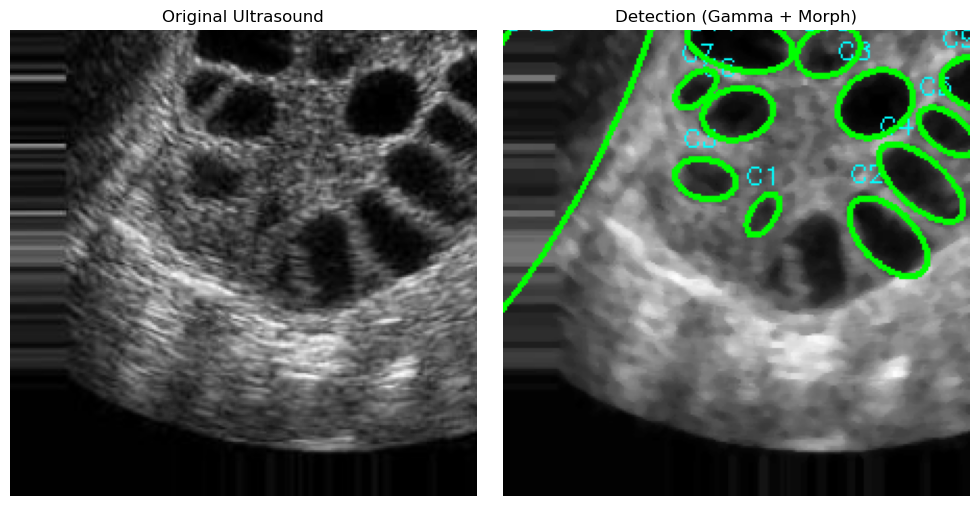

In [73]:
seg.compare_images(enhanced_img)

In [66]:
class ManualModel():
    def __init__(self, train_dataset):
        self.train_dataset = train_dataset
    
    def infer_labels(self, threshold=5):

        labels = []
        inferred_labels = []
        hit = []

        for i, j in enumerate(self.train_dataset):
            img, label = train_dataset[i]

            img_np = img.squeeze(0).numpy()
            seg = ImageSegmentation(img_np)
            new_image = seg.intensity_transformation()
            filtered_image = seg.spatial_filtering(new_image)
            enhanced_img, count = seg.apply_pipeline()
            labels.append(label)

            inferred_label = 0 if count > threshold else 1
            
            inferred_labels.append(inferred_label)
            
            [hit.append(1) if label == inferred_label else hit.append(0)]

        print(len(labels), len(hit))
        
        return pd.DataFrame({"label": labels, "inferred_label": inferred_labels, "hit": hit})
    
    def evaluate(self, pd):
        accuracy = sum(pd["hit"]) / len(pd)

        return accuracy

In [70]:
MM = ManualModel(train_dataset)
pd = MM.infer_labels()


1924 1924


In [71]:
MM.evaluate(pd)

0.7001039501039501

## CNN model

In [33]:
class CNNModel:
    
    
    pass

In [34]:
class Train:
  pass

In [35]:
class Evaluation:
  pass